# CO2 Emmissions by cars 


## **Project Definition and Goal**<br>  <span style="color: red;">Imrpove</span>




### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA <span style="color: red;">improve.</span>



| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [367]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [368]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')

C:\Users\silva\AppData\Local\Temp\ipykernel_3016\1031381680.py:3: DtypeWarning: Columns (3,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')


## **First Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [369]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734898 entries, 0 to 10734897
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables don't appear in the variables explanation in the EEA website </span>
- ech
- RLFI

Let's see how our table looks like

In [370]:
#extended version of the code
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,131946501,DE,IP-2021_536K7F-YV1-1,NaN,VOLVO,VOLVO CAR CORPORATION,NaN,E9*2007/46*3146*17,X,XZK7,XZK7VF0,VOLVO,XC40,M1,M1,1,1688.0,1822.0,NaN,153.0,NaN,NaN,NaN,petrol,H,1969.0,120.0,NaN,NaN,NaN,NaN,NaN,NaN,F,2023,2023-11-06,6.7,Euro 6 AP,RL-2146CMAHI536FVX-YV1-1,NaN
1,131946502,DE,IP-03_MP_0298-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,E3*2007/46*0508*15,MP,JH7FA,MN1BAHR,JEEP,COMPASS,M1,M1,1,1575.0,1696.0,NaN,133.0,NaN,NaN,NaN,petrol,H,1469.0,96.0,NaN,e3 37 32,NaN,2.2,NaN,NaN,F,2023,2023-05-25,5.8,NaN,RL-03_334_BU_0111-ZFA-1,NaN
2,131946503,DE,IP-MQB27ZZ_A1_0529-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,E1*2007/46*1892*30,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,AUDI,A1 SPORTBACK,M1,M1,1,1175.0,1294.0,NaN,129.0,NaN,NaN,NaN,petrol,M,999.0,70.0,NaN,e13 29,NaN,1.1,NaN,NaN,F,2023,2023-03-20,5.7,NaN,RL-MQ200_5F_20_001-WVW-1,NaN
3,131946504,DE,IP-MQB27ZZ_A0_1005-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,NaN,E8*2018/858*00014*05,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,SKODA,FABIA,M1,M1,1,1122.0,1232.0,NaN,117.0,NaN,NaN,NaN,petrol,M,999.0,59.0,NaN,e8 29 37,NaN,1.9,NaN,NaN,F,2023,2023-08-03,5.2,NaN,NaN,NaN
4,131946505,DE,IP-SC2E_2-LGX-1,NaN,BYD,BYD AUTO INDUSTRY COMPANY LIMITED,NaN,E9*2018/858*11147*01,SC2E,M2F1C,1NXE5E001NL1,BYD,ATTO 3,M1,M1,1,1825.0,1897.0,NaN,0.0,NaN,NaN,NaN,electric,E,NaN,150.0,160.0,NaN,NaN,NaN,NaN,NaN,F,2023,2023-08-04,NaN,NaN,RL-SC2E_2-LGX-1,420.0


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734893,124068626,ES,IP-MQB37WZ_A2_1014-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,E1*2007/46*2014*23,CD,ACDTRBX0,FD7FD7CW002N4BISON1VL1AVR2AIM,VOLKSWAGEN,GOLF,M1,M1,1,1387.0,1495.0,NaN,117.0,NaN,NaN,NaN,diesel,M,1968.0,85.0,NaN,e13 29 37,NaN,1.7,NaN,NaN,F,2023,2023-11-13,4.5,EURO 6AP,NaN,NaN
10734894,124068627,ES,IP-13_2022_501-JMZ-1,MAZDA,MAZDA,MAZDA MOTOR CORPORATION,NaN,E13*2018/858*00255*03,KH01,4BC,D6MWAXABXA,MAZDA,MAZDA CX-60,M1,M1,1,2070.0,2245.0,NaN,33.0,NaN,NaN,NaN,petrol/electric,P,2488.0,141.0,230.0,NaN,NaN,NaN,NaN,NaN,F,2023,2023-03-21,1.5,AP,NaN,63.0
10734895,124068628,ES,IP-050054-KNA-1,KIA,KIA,KIA CORPORATION,NaN,E5*2007/46*1078*07,JA,F5PB1,M55DZ1,KIA,PICANTO,M1,M1,1,983.0,1116.0,NaN,119.0,NaN,NaN,NaN,petrol,M,1197.0,62.0,NaN,e5 29,NaN,1.0,NaN,NaN,F,2023,2023-12-28,5.2,EURO 6AP,NaN,NaN
10734896,124068629,ES,IP-0104-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,E6*2007/46*0289*06,"XA5(EU,M)",AXAL52(N),AXAL52L-ANXMBW(1G),TOYOTA,TOYOTA RAV4,M1,M1,1,1665.0,1774.0,NaN,129.0,NaN,NaN,NaN,petrol,H,2487.0,131.0,NaN,e6 37,NaN,0.6,NaN,NaN,F,2023,2023-01-17,5.7,EURO 6AP,NaN,NaN
10734897,124068630,ES,IP-MQB27ZZ_A1_1005-VSS-1,VOLKSWAGEN,SEAT,SEAT SA,NaN,E9*2007/46*3134*39,KJ,BDSGD,FM5SFM5DF0104BI1A1AAEA8D,SEAT,IBIZA,M1,M1,1,1121.0,1208.0,NaN,120.0,NaN,NaN,NaN,petrol,M,999.0,59.0,NaN,e9 29 37,NaN,1.8,NaN,NaN,F,2023,2023-03-21,5.3,EURO 6AP,NaN,NaN


### Data Translation

In [371]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Fuel consumption ':'Fuel_consumption',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [372]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [373]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel_consumption', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

### handling zeros for Variables that have only zeros

In [374]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734898 entries, 0 to 10734897
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [375]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734898           0              0.0
                                    Country    object        10734898           0              0.0
                   Vehicle_Family_id_number    object        10604452      130446              1.2
                       Manufacturer_Pooling    object         9774661      960237              8.9
                          Manufacturer_Name    object        10734898           0              0.0
                      Manufacturer_name_OEM    object        10734898           0              0.0
                       Manufacturer_name_MS   float64               0    10734898            100.0
                       Type_approval_number    object        10702447       32451              0.3
                                       Type    object        10729060        5838              0.1
          

 Missing Data Analysis - Key Insights:

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

Electric Vehicle Features (High Missing %):

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Most probably the non-Electric Vehicles do not have the respective features. It should be double checked

Important Features (Moderate Missing):

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

Clean Features (Low Missing):

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [376]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [377]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

### handling duplicates

In [378]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

### categorical variables exploration



In [379]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Date of registration', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2754918 (25.7%)
    FR: 1889602 (17.6%)
    IT: 1564282 (14.6%)
    ES: 974230 (9.1%)
    BE: 476617 (4.4%)
    PL: 474383 (4.4%)
    NL: 364750 (3.4%)
    SE: 294411 (2.7%)
    AT: 238543 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 4524
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 193364 (1.8%)
    IP-0153-JT1-1: 129500 (1.2%)
    IP-0110-JT1-1: 104369 (1.0%)
    IP-JAA1MTPJT4A_000-VF1-1: 83916 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69234 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 65653 (0.

### General Overview of Categorical Variables


- The most of the variable should be interpreted properly. We don't know how to interpret the values in the following categorical variables: 
    - Vehicle_Family_id_number
    - Type_approval_number
    - Type
    - Variant
    - Version
    - Category_type_approved
    - Fuel_Mode
    - Innovative_Technologies
    - Electric_Charge
    - RLFI



### Modalities of Fuel Type reduction

In [380]:
# Create a mapping dictionary for standardization
fuel_mapping = {
    'PETROL': 'petrol',
    'DIESEL': 'diesel', 
    'ELECTRIC': 'electric',
    'PETROL/ELECTRIC': 'petrol/electric',
    'LPG': 'lpg',
    'e85': 'petrol'
}

# Apply the mapping
df_a['Fuel_Type'] = df_a['Fuel_Type'].replace(fuel_mapping)

# Check the result
print(df_a['Fuel_Type'].value_counts())

Fuel_Type
petrol             6092556
diesel             1821879
electric           1669214
petrol/electric     807659
lpg                 292506
diesel/electric      29624
ng                    7364
hydrogen               730
Name: count, dtype: int64


### exploring other unuseful features

In [381]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel_consumption,Electric range (km)
count,10721532.0,10721532.0,10721379.0,10572219.0,10721532.0,9051526.0,10671036.0,2436503.0,6944544.0,10721532.0,8845256.0,2427430.0
mean,125979675.9,1.0,1544.2,1658.1,106.5,1543.5,115.1,172.0,1.5,2023.0,5.4,312.8
std,8080378.9,0.0,360.1,376.8,59.6,524.6,62.8,28.5,0.5,0.0,1.8,193.2
min,3.0,1.0,563.0,615.0,0.0,658.0,8.0,12.0,0.5,2023.0,0.1,12.0
25%,122186059.8,1.0,1270.0,1375.0,100.0,1197.0,74.0,155.0,1.1,2023.0,4.9,75.0
50%,128888763.5,1.0,1478.0,1585.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,362.0
75%,131879361.2,1.0,1760.0,1889.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.2,488.0
max,140000058.0,1.0,4953.0,4574.0,572.0,7993.0,1177.0,600.0,3.0,2023.0,25.2,883.0


The following numerical columns have only 1 value and they will not be used in modeling steps
- Total_new_registrations
- year

These variables are candidate to drop. We will drop them later

In [382]:
df_a.shape

(10721532, 32)

In [383]:
df_a.head(5)

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
0,131946501,DE,IP-2021_536K7F-YV1-1,NaN,VOLVO,VOLVO CAR CORPORATION,E9*2007/46*3146*17,X,XZK7,XZK7VF0,VOLVO,XC40,M1,M1,1,1688.0,1822.0,153.0,petrol,H,1969.0,120.0,NaN,NaN,NaN,F,2023,2023-11-06,6.7,Euro 6 AP,RL-2146CMAHI536FVX-YV1-1,NaN
1,131946502,DE,IP-03_MP_0298-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,E3*2007/46*0508*15,MP,JH7FA,MN1BAHR,JEEP,COMPASS,M1,M1,1,1575.0,1696.0,133.0,petrol,H,1469.0,96.0,NaN,e3 37 32,2.2,F,2023,2023-05-25,5.8,NaN,RL-03_334_BU_0111-ZFA-1,NaN
2,131946503,DE,IP-MQB27ZZ_A1_0529-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,E1*2007/46*1892*30,GB,SDLACF1,FM5FM5DF008RT11B174BIAEM10B0,AUDI,A1 SPORTBACK,M1,M1,1,1175.0,1294.0,129.0,petrol,M,999.0,70.0,NaN,e13 29,1.1,F,2023,2023-03-20,5.7,NaN,RL-MQ200_5F_20_001-WVW-1,NaN
3,131946504,DE,IP-MQB27ZZ_A0_1005-TMB-1,VOLKSWAGEN,SKODA,SKODA AUTO AS,E8*2018/858*00014*05,PJ,ABDSGDX0,NFM5FM5DF0104BI3N1A1A,SKODA,FABIA,M1,M1,1,1122.0,1232.0,117.0,petrol,M,999.0,59.0,NaN,e8 29 37,1.9,F,2023,2023-08-03,5.2,NaN,NaN,NaN
4,131946505,DE,IP-SC2E_2-LGX-1,NaN,BYD,BYD AUTO INDUSTRY COMPANY LIMITED,E9*2018/858*11147*01,SC2E,M2F1C,1NXE5E001NL1,BYD,ATTO 3,M1,M1,1,1825.0,1897.0,0.0,electric,E,NaN,150.0,160.0,NaN,NaN,F,2023,2023-08-04,NaN,NaN,RL-SC2E_2-LGX-1,420.0


## **Data Reduction**<br> 
- Filtering for "only Combustion" motor cars, using unique values <br> 
- selecting variables that make sense to study combustion <br>
- handling variables with high Zero content

### Filtering Petrol and Diesel

In [384]:
# Filtering the DataFrame to include only petrol and diesel vehicles
df_a = df_a[df_a['Fuel_Type'].isin(['petrol', 'diesel'])]

# Displaying the shape of the DataFrame after filtering
df_a.shape

(7914435, 32)

In [385]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol    6092556
diesel    1821879
Name: count, dtype: int64

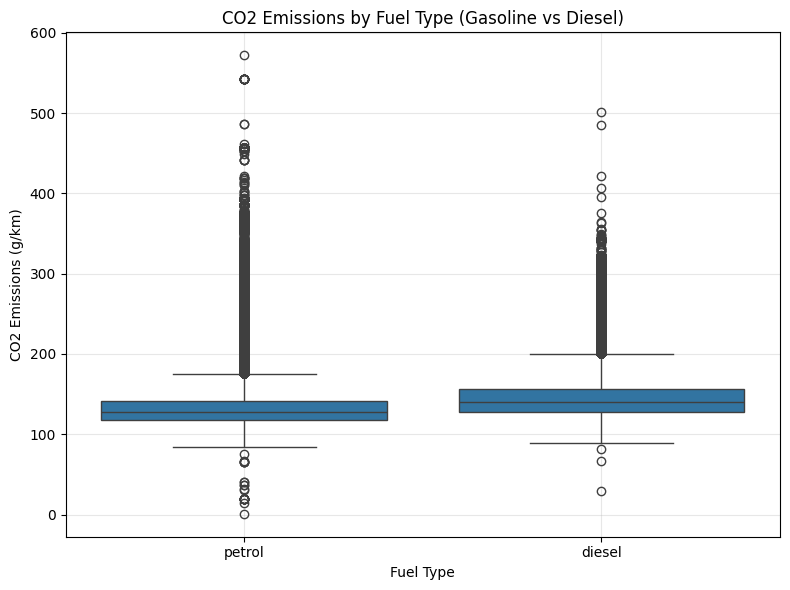

In [386]:
# Create the boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel_Type', y='CO2_Emissions_WLTP(g/km)', data=df_a)
plt.title('CO2 Emissions by Fuel Type (Gasoline vs Diesel)')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### are Petro and Diesel significant different?

are petrol and diesel significant difference?

In [387]:
from scipy.stats import mannwhitneyu

# Filter data
co2_petrol = df_a[df_a['Fuel_Type'] == 'petrol']['CO2_Emissions_WLTP(g/km)']
co2_diesel = df_a[df_a['Fuel_Type'] == 'diesel']['CO2_Emissions_WLTP(g/km)']

# Perform Mann–Whitney U test
u_stat, p_value = mannwhitneyu(co2_petrol, co2_diesel, alternative='two-sided')

print("Mann–Whitney U Test")
print(f"U statistic = {u_stat}")
print(f"P-value = {p_value:.6f}")

# Interpret
alpha = 0.05
if p_value < alpha:
    print("✅ Statistically significant difference between petrol and diesel CO₂ emissions.")
else:
    print("❌ No statistically significant difference between petrol and diesel CO₂ emissions.")

Mann–Whitney U Test
U statistic = 3586760551499.5
P-value = 0.000000
✅ Statistically significant difference between petrol and diesel CO₂ emissions.


This is important to consider, we should keep this variable, because the CO2 Emissions are considerable different

### Applying Unique Values to find only unique auto models

In [388]:
df_unique = df_a.drop_duplicates(subset=['Version', 'Variant', 'Type','CO2_Emissions_WLTP(g/km)'])

In [389]:
df_a.shape

(7914435, 32)

In [390]:
df_unique.shape

(101190, 32)

### Exploring and selecting the rest of the variables

In [391]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64          101190           0              0.0
                                    Country    object          101190           0              0.0
                   Vehicle_Family_id_number    object           98344        2846              2.8
                       Manufacturer_Pooling    object           93111        8079              8.0
                          Manufacturer_Name    object          101190           0              0.0
                      Manufacturer_name_OEM    object          101190           0              0.0
                       Type_approval_number    object           99611        1579              1.6
                                       Type    object          101048         142              0.1
                                    Variant    object           99506        1684              1.7
          

Drop columns: <br>
Vehicle_Family_id_number - the model of the car is already described by other variables <br>
Manufacturer_Pooling - the model of the car is already described by other variables <br>
Manufacturer_Name - the model of the car is already described by other variables <br>
Manufacturer_name_OEM - the model of the car is already described by other variables <br>
Manufacturer_name_MS - the model of the car is already described by other variables <br>
Type_approval_number - the model of the car is already described by other variables <br>
Type - we used it for the filtering but we dont need it anymore <br>
Variant - we used it for the filtering but we dont need it anymore<br>
Version - we used it for the filtering but we dont need it anymore <br>
Make - not relevant for CO2 <br>
Commercial_Name - we used it for the filtering but we dont need it anymore <br>
Category_type_approved - not relevant for CO2 <br>
Category_type_registered - not relevant for CO2 <br>
Total_new_registrations - not relevant for CO2 <br>
Mass_in_Running_Order(kg) - stay <br>
WLTP_test_mass - stay <br>
CO2_Emissions_NEDC(g/km) - the whole is zeros <br>
CO2_Emissions_WLTP(g/km) - our target <br>
Wheelbase(mm) - the whole is zeros <br>
Axle_Track_1(mm) - the whole is zeros <br>
Axle_Track_2(mm) - the whole is zeros<br>
Fuel_Type - we should keep it<br>
Fuel_Mode - stay<br>
Engine_Capacity(cm3) - stay<br>
Engine_Power(kW) - stay<br>
Electric_Energy_Consumption(Wh/km) - not relevant for Combustion<br>
Innovative_Technologies - 35% of zeros, delete<br>
Emmission_reduction_through_innovation - 30& of zeros, delete<br>
Emmission_reduction_through_innovation_WLTP - 30% of zeros, delete<br>
Deviation_factor - 100% of zeros, delete<br>
Verification_factor - 100% of zeros, delete<br>
Status - delete not relevant for study<br>
 year - delete not relevant for study<br>
Date of registration - delete, not relevant for study<br>
Fuel consumption - stay<br>
Electric_Charge - not relevant for Combustion<br>
RLFI - Delete, a lot of zeros
Electric range (km) - delete, not relevant for study<br>

#### Dropping columns that are meaningless

In [392]:
columns_to_drop = ['Vehicle_ID','Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Country',
                   'Type','Variant', 'Version','Commercial_Name', 'Type_approval_number', 'Make', 'Category_type_approved', 
                   'Category_type_registered','Total_new_registrations','Electric_Energy_Consumption(Wh/km)','year',
                   'Emmission_reduction_through_innovation_WLTP',
                   'Status','Date of registration','Electric_Charge','RLFI', 'Electric range (km)' ]

df_unique = df_unique.drop(columns_to_drop, axis=1)

#### what about Fuel mode? what is it behind? <--- FIltering "M"

In [393]:
df_unique['Fuel_Mode'].value_counts()

Fuel_Mode
M    65138
H    36018
F       34
Name: count, dtype: int64

This fuel modes are the way they do the tests in the emission tests. We should stick only to onw of those

Fuel_Mode Codes Explained

| Code | Meaning                        | Description                                                                 |
|------|--------------------------------|-----------------------------------------------------------------------------|
| **M** | **Mixed** or **Combined Mode** | This is the standard test mode combining **urban and extra-urban cycles**, or a **weighted average** of several driving phases (used in WLTP or NEDC cycles). |
| **H** | **High** or **Extra-Urban**    | Refers to higher-speed or **extra-urban driving conditions** (e.g., highway). Often used to isolate performance/emissions in faster driving. |
| **F** | **Full Power / Fast / Urban Cold** (less common) | Could refer to a cold start cycle, or a specific **urban test cycle**, but with only 36 entries it's probably a rare, legacy, or test-specific label. |

In [394]:
df_unique = df_unique[df_unique['Fuel_Mode']== 'M']

In [395]:
df_unique.shape

(65138, 9)

#### Looking for Multicolinearities <--- Deleting Fuel Consumption and Mass WLTP

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel_consumption                                   0.95
Mass_in_Running_Order(kg)                          0.81
WLTP_test_mass                                     0.80
Engine_Capacity(cm3)                               0.67
Engine_Power(kW)                                   0.66


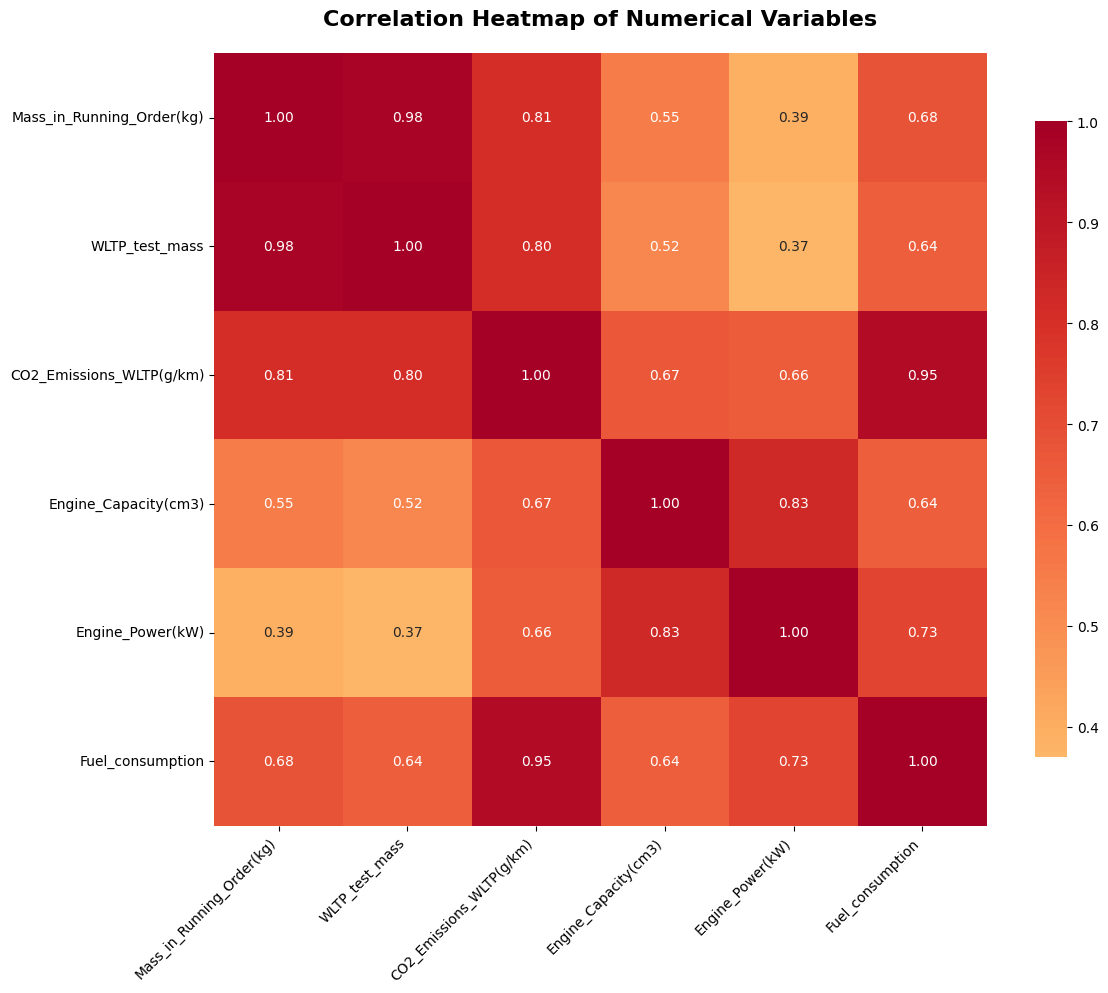

In [396]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_unique.select_dtypes(include=[np.number]).columns

#display(numerical_cols)

corr_with_co2 = df_unique[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_unique[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [397]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Fuel_consumption',
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_unique[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)


VIF Values:
                     Feature   VIF
4  Mass_in_Running_Order(kg) 811.5
3             WLTP_test_mass 672.4
0           Fuel_consumption  60.1
1       Engine_Capacity(cm3)  52.4
2           Engine_Power(kW)  29.3


##### Droping WLTP Mass

serious multi-colinearity between Mass_in_Running_Order(kg) and WLTP_test_mass, we'll delete the one with mroe zeros

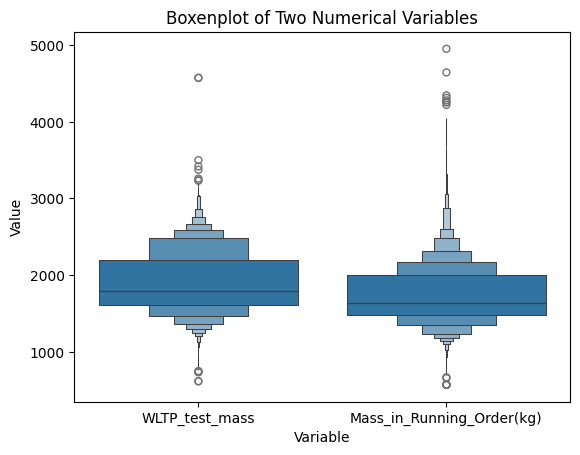

In [398]:

# Pick two numerical columns
cols = ['WLTP_test_mass', 'Mass_in_Running_Order(kg)']

# Melt the data
df_melted = df_unique[cols].melt(var_name='Variable', value_name='Value')

# Plot
sns.boxenplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxenplot of Two Numerical Variables')
plt.show()

In [399]:
#calculating the difference in means
difference_masses = df_unique['WLTP_test_mass'].mean() - df_unique['Mass_in_Running_Order(kg)'].mean() 

In [400]:
df_unique['Mass_in_Running_Order(kg)'] = df_unique['Mass_in_Running_Order(kg)'].fillna(
    df_unique['WLTP_test_mass'] - difference_masses)

In [401]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65125          13              0.0
           WLTP_test_mass   float64           62839        2299              3.5
 CO2_Emissions_WLTP(g/km)   float64           65138           0              0.0
                Fuel_Type    object           65138           0              0.0
                Fuel_Mode    object           65138           0              0.0
     Engine_Capacity(cm3)   float64           65115          23              0.0
         Engine_Power(kW)   float64           65085          53              0.1
  Innovative_Technologies    object           53646       11492             17.6
         Fuel_consumption   float64           61086        4052              6.2


still some NA in Mass_in_Running_Order(kg), lets drop na values

In [402]:
df_unique=  df_unique.dropna(subset=['Mass_in_Running_Order(kg)'])

In [403]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65125           0              0.0
           WLTP_test_mass   float64           62839        2286              3.5
 CO2_Emissions_WLTP(g/km)   float64           65125           0              0.0
                Fuel_Type    object           65125           0              0.0
                Fuel_Mode    object           65125           0              0.0
     Engine_Capacity(cm3)   float64           65104          21              0.0
         Engine_Power(kW)   float64           65073          52              0.1
  Innovative_Technologies    object           53645       11480             17.6
         Fuel_consumption   float64           61077        4048              6.2


now we drop the WLTP_test_mass

In [404]:

df_unique = df_unique.drop('WLTP_test_mass', axis=1)

In [405]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65125           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           65125           0              0.0
                Fuel_Type    object           65125           0              0.0
                Fuel_Mode    object           65125           0              0.0
     Engine_Capacity(cm3)   float64           65104          21              0.0
         Engine_Power(kW)   float64           65073          52              0.1
  Innovative_Technologies    object           53645       11480             17.6
         Fuel_consumption   float64           61077        4048              6.2


##### Dropping Fuel Consumption

Fuel_consumption and CO2 are very high correlated (0.97) and also has 20% of missing data, thus we'll drop it

In [406]:
df_unique = df_unique.drop('Fuel_consumption', axis=1)

In [407]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65125           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           65125           0              0.0
                Fuel_Type    object           65125           0              0.0
                Fuel_Mode    object           65125           0              0.0
     Engine_Capacity(cm3)   float64           65104          21              0.0
         Engine_Power(kW)   float64           65073          52              0.1
  Innovative_Technologies    object           53645       11480             17.6


In [408]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_unique[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)

VIF Values:
                     Feature  VIF
0       Engine_Capacity(cm3) 42.8
1           Engine_Power(kW) 17.3
2  Mass_in_Running_Order(kg) 16.7


#### Deleting Innovative Technlogies <--- It has high cardinality, 30 percent zeros, very low interpretability and low predictive power

In [409]:
df_unique['Innovative_Technologies'].value_counts(normalize=True)

Innovative_Technologies
e1 29       0.3
e8 29 37    0.1
e13 29 37   0.1
e9 29 37    0.1
e1 29 37    0.1
             ..
e1 08       0.0
e4 29       0.0
e4 33 37    0.0
e637        0.0
e8 28 37    0.0
Name: proportion, Length: 89, dtype: float64

Innovative Technologies has a very high cardinality and very low interpretability maybe we should drop it. <br>
lets do a quick test to see its predictive power

In [410]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Simple encoding for testing
df_copy = df_unique.copy()
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype(str)
df_copy['Innovative_Technologies'] = df_copy['Innovative_Technologies'].astype('category').cat.codes

X = df_copy[['Innovative_Technologies']]
y = df_copy['CO2_Emissions_WLTP(g/km)']  

clf = RandomForestClassifier()
score = cross_val_score(clf, X, y, cv=5).mean()
print("Mean CV Accuracy:", score)

c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Mean CV Accuracy: 0.025704414587332053


This confirms what we said, this variable should be deleted

In [411]:
df_unique = df_unique.drop('Innovative_Technologies', axis = 1)

### Handling Zeros


In [412]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65125           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           65125           0              0.0
                Fuel_Type    object           65125           0              0.0
                Fuel_Mode    object           65125           0              0.0
     Engine_Capacity(cm3)   float64           65104          21              0.0
         Engine_Power(kW)   float64           65073          52              0.1


In [413]:
df_unique=  df_unique.dropna(subset=['Engine_Capacity(cm3)','Engine_Power(kW)'])

In [414]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           65072           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           65072           0              0.0
                Fuel_Type    object           65072           0              0.0
                Fuel_Mode    object           65072           0              0.0
     Engine_Capacity(cm3)   float64           65072           0              0.0
         Engine_Power(kW)   float64           65072           0              0.0


## **TARGET VARIABLE ANALYSIS: CO2 (g/km)** - after filtering

In [415]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_unique['CO2_Emissions_WLTP(g/km)'].describe())

count   65072.0
mean      169.7
std        42.9
min         1.0
25%       137.0
50%       157.0
75%       196.0
max       572.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

C:\Users\silva\AppData\Local\Temp\ipykernel_3016\1977143025.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\silva\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


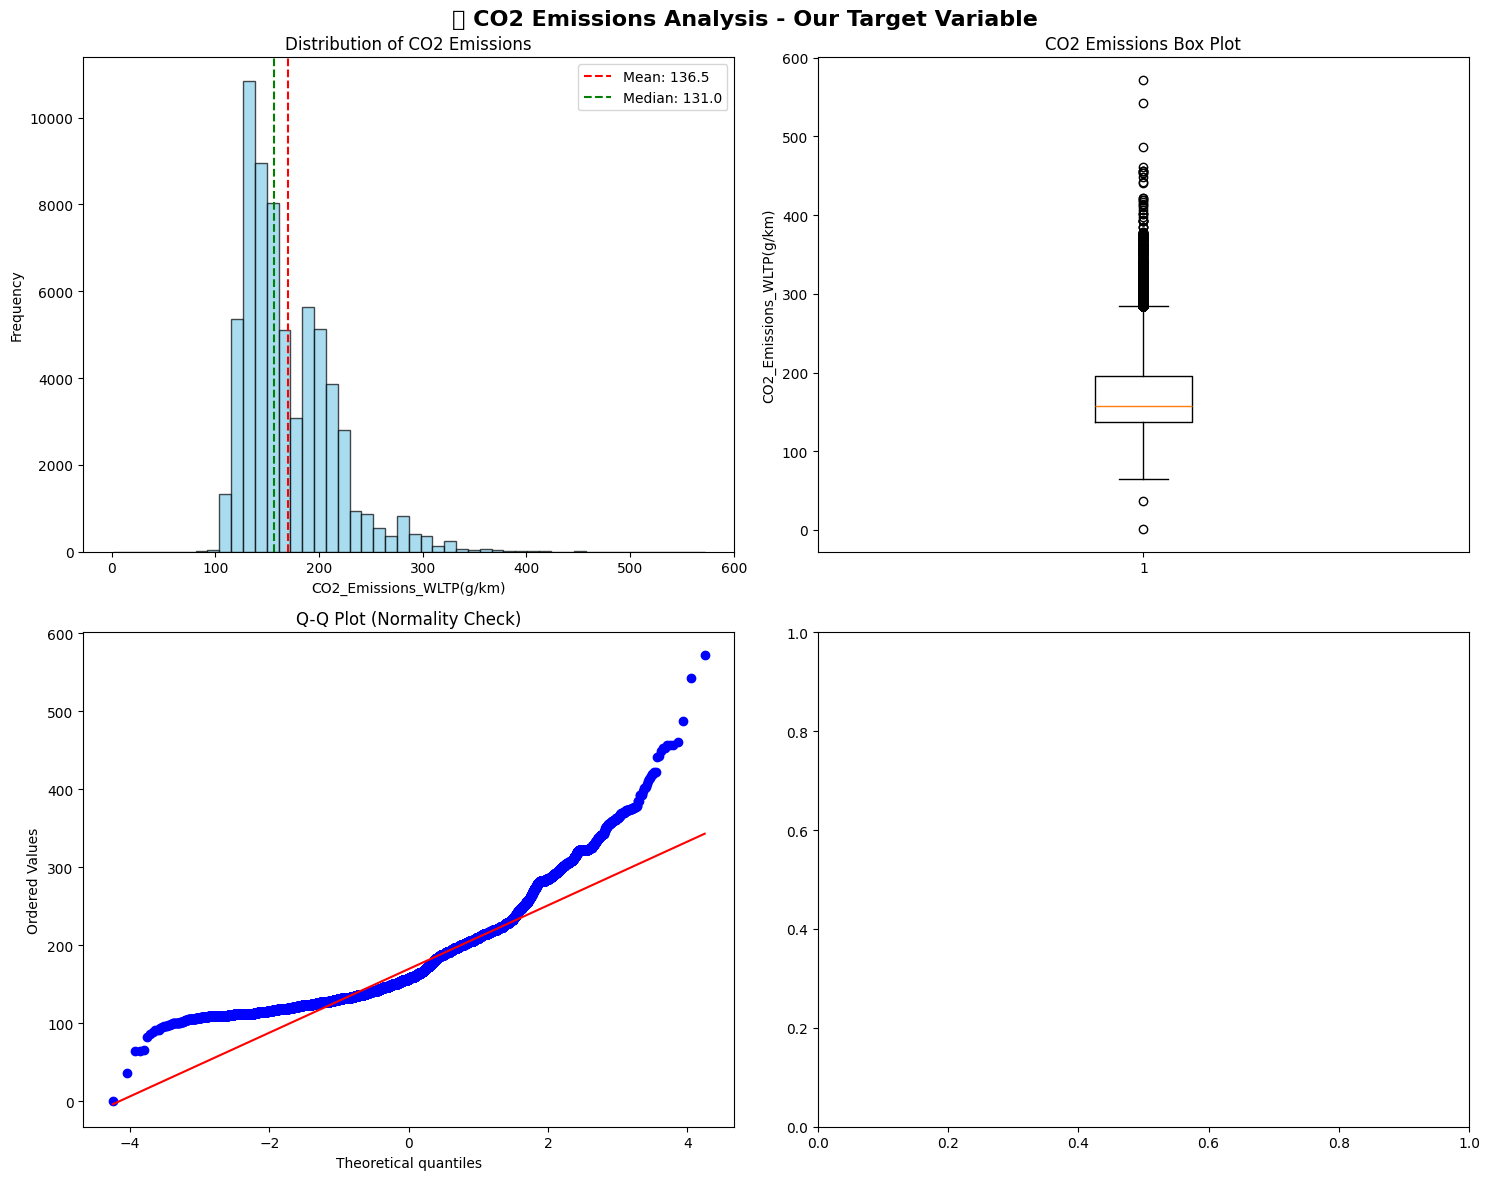

In [416]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_unique['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_unique['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_unique['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_unique['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_unique['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()

Q-Q PLOT: The data shows that the Distribution is not Normal, we should consider this for the model steps. We should use a model that does not suppose normal distribution

In [417]:
df_a.shape

(7914435, 32)

## Does <span style="color:orange"> Engine Capacity </span> has a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.668377
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.500753
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.446728
   Interpretation: 44.67% of variance in CO2 emissions is explained by engine capacity


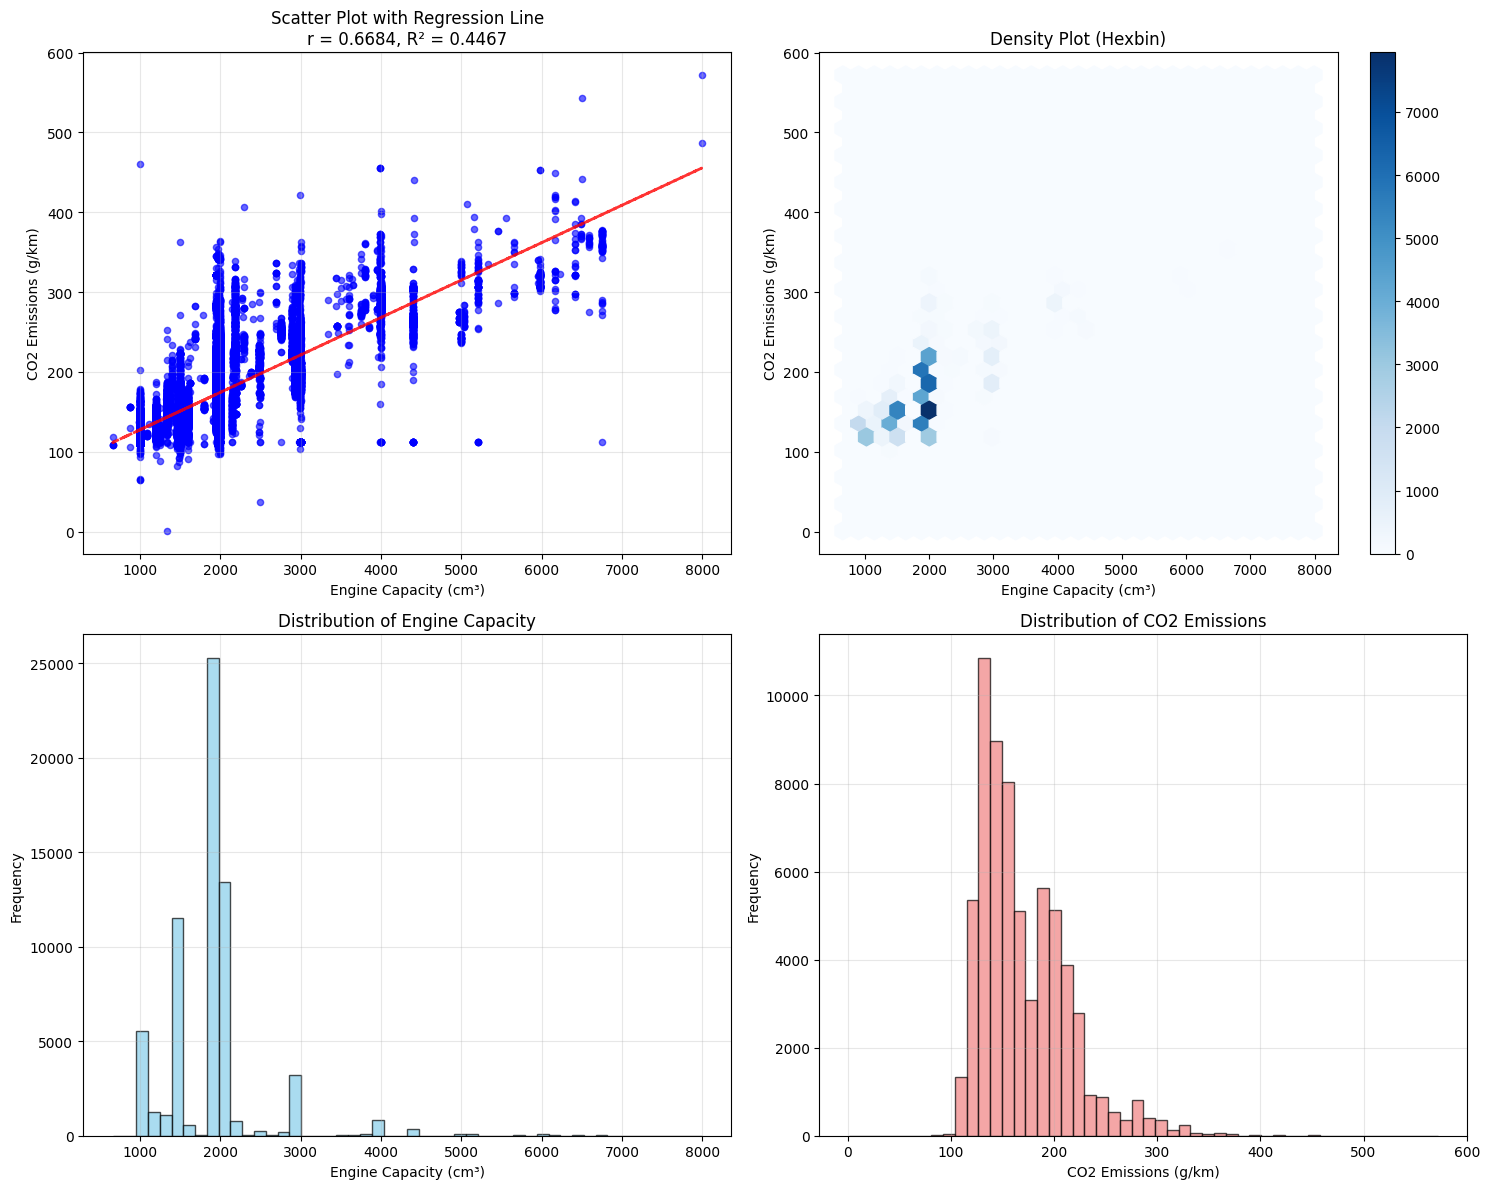


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 44.67% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.5008) is much different from Pearson correlation (0.6684),
this suggests a non-linear monotonic relationship might exist.


In [418]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Capacity(cm3)'], p(df_unique['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does <span style="color:orange"> Engine Power </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between fuel consumoption and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between fuel consumoption and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.656178
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.655830
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.430569
   Interpretation: 43.06% of variance in CO2 emissions is explained by engine capacity


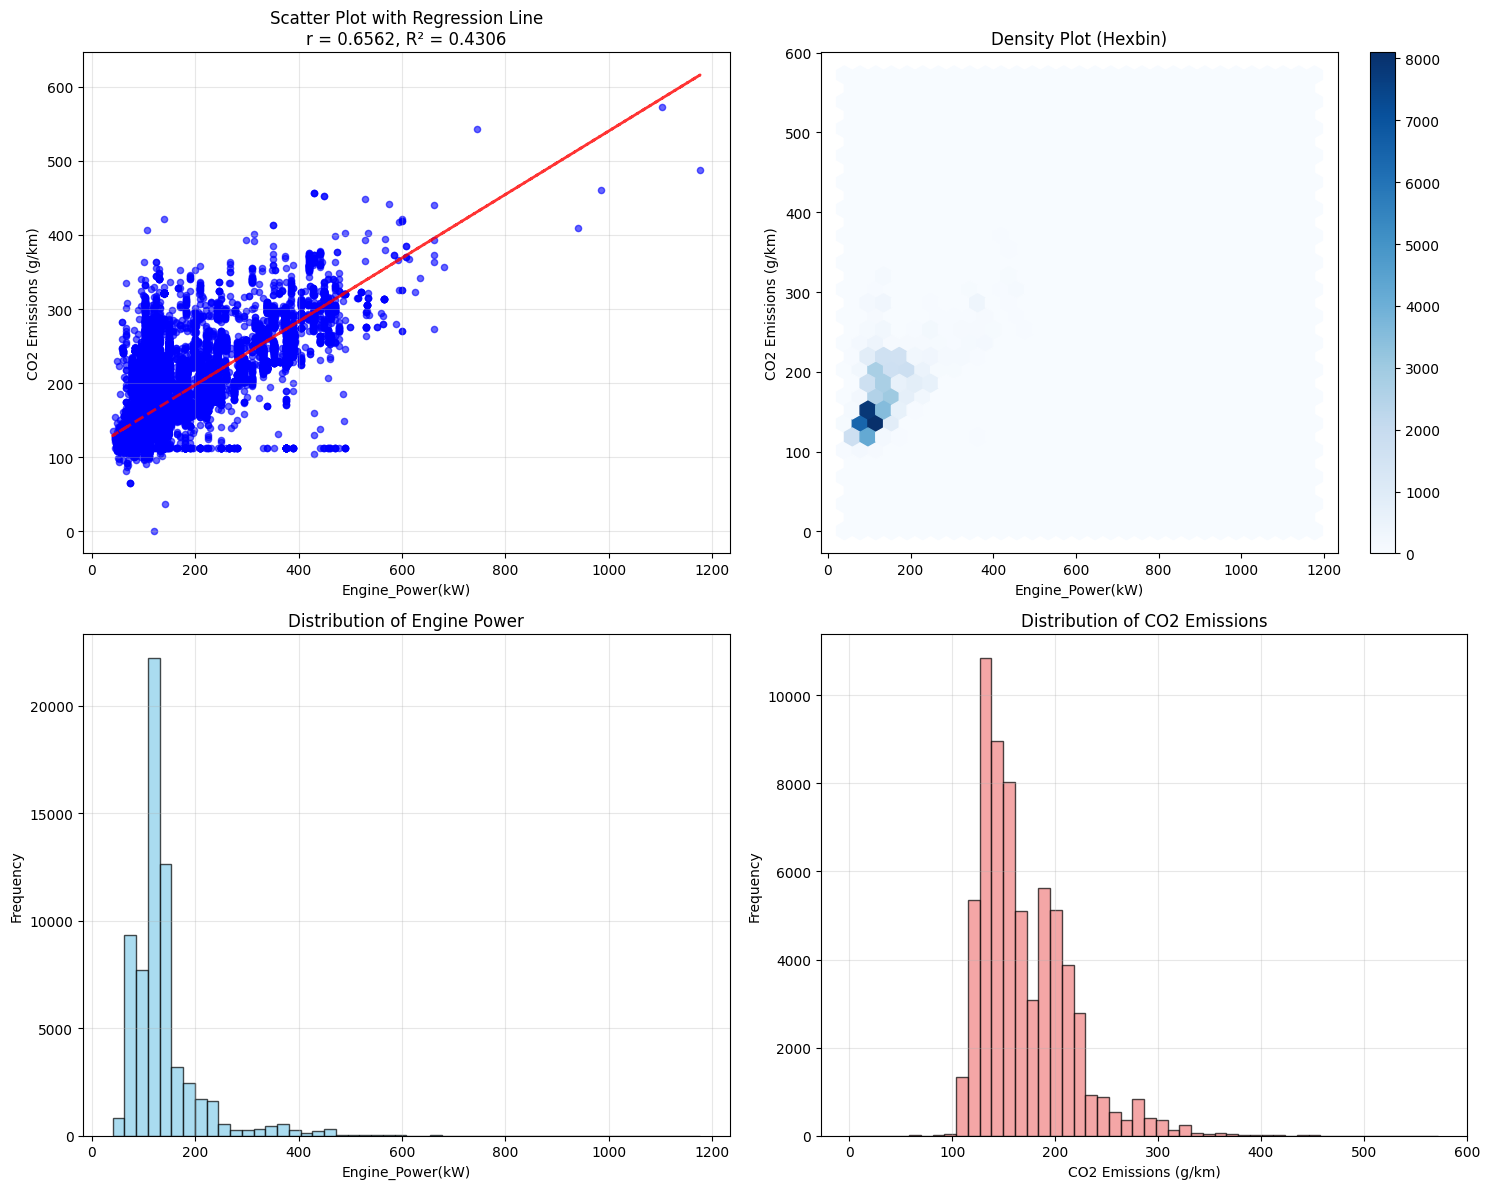


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 43.06% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.6558) is much different from Pearson correlation (0.6562),
this suggests a non-linear monotonic relationship might exist.


In [419]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Power(kW)'], p(df_unique['Engine_Power(kW)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine_Power(kW)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine_Power(kW)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Power(kW)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine_Power(kW)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Power')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does <span style="color:orange"> Mass </span> have a relationship with CO2 Emissions

- Null Hypothesis (H₀): There is no linear relationship between Mass and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between Mass and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased Mass.

=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.810990
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.837716
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Very Strong positive linear relationship
Spearman: Very Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.657705
   Interpretation: 65.77% of variance in CO2 emissions is explained by mass


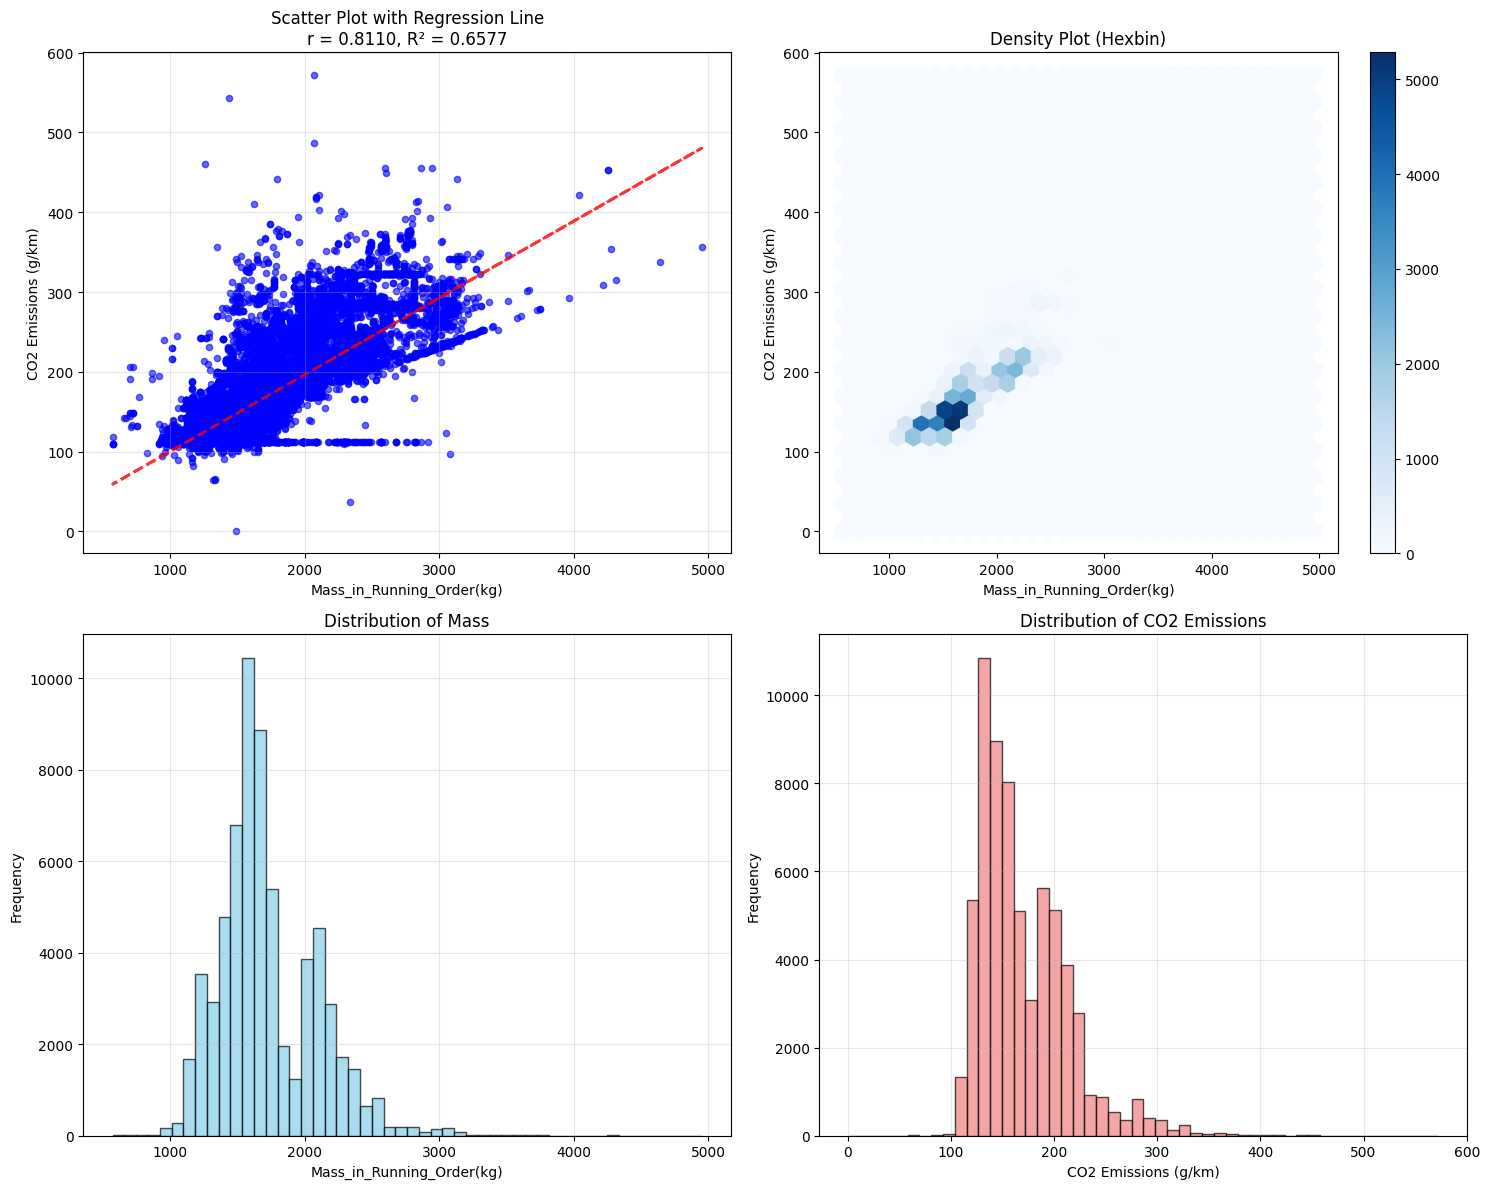


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is very strong and positive.
Engine capacity explains 65.77% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.8377) is much different from Pearson correlation (0.8110),
this suggests a non-linear monotonic relationship might exist.


In [420]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by mass")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Mass_in_Running_Order(kg)'], p(df_unique['Mass_in_Running_Order(kg)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Mass_in_Running_Order(kg)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Mass')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

### DF After Variable Reduction

In [421]:
df_unique.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
2,1175.0,129.0,petrol,M,999.0,70.0
3,1122.0,117.0,petrol,M,999.0,59.0
6,1588.0,126.0,diesel,M,1968.0,110.0
7,1516.0,124.0,diesel,M,1968.0,110.0
10,1349.0,126.0,petrol,M,1498.0,110.0


In [422]:
df_unique['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
diesel   0.5
petrol   0.5
Name: proportion, dtype: float64

In [423]:
df_unique.shape

(65072, 6)

## Handling Outliers

### For CO2 <--- Deleting lower bound

In [424]:
Q1 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.25)
Q3 = df_unique['CO2_Emissions_WLTP(g/km)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound) |
    (df_unique['CO2_Emissions_WLTP(g/km)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 1564


In [425]:
outliers_iqr

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
132,2410.0,306.0,petrol,M,4395.0,460.0
623,1970.0,299.0,petrol,M,3982.0,430.0
750,1645.0,285.0,petrol,M,3745.0,405.0
1035,2220.0,297.0,petrol,M,3996.0,338.0
1443,2815.0,292.0,diesel,M,2993.0,183.0
...,...,...,...,...,...,...
10685969,2511.0,320.0,petrol,M,5950.0,485.0
10717149,2881.0,294.0,diesel,M,2184.0,103.0
10723565,3058.0,407.0,diesel,M,2299.0,107.0
10723732,2589.0,294.0,petrol,M,3996.0,404.0


In [426]:
df_unique[df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
342101,1485.0,1.0,petrol,M,1332.0,120.0
2475457,2333.0,37.0,petrol,M,2488.0,141.0


We'll delete this two

In [427]:
df_unique = df_unique[~(df_unique['CO2_Emissions_WLTP(g/km)'] < lower_bound)]

### for Engine Capacity <--- Nothing to delete

In [428]:
Q1 = df_unique['Engine_Capacity(cm3)'].quantile(0.25)
Q3 = df_unique['Engine_Capacity(cm3)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Capacity(cm3)'] < lower_bound) |
    (df_unique['Engine_Capacity(cm3)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 5161


In [429]:
df_unique[df_unique['Engine_Capacity(cm3)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
67407,570.0,109.0,petrol,M,658.0,63.0
2242900,570.0,119.0,petrol,M,658.0,63.0
3486192,570.0,109.0,petrol,M,658.0,63.0
9385547,570.0,109.0,petrol,M,658.0,63.0
9934683,570.0,109.0,petrol,M,658.0,63.0


In [430]:
df_unique[df_unique['Engine_Capacity(cm3)'] < upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
2,1175.0,129.0,petrol,M,999.0,70.0
3,1122.0,117.0,petrol,M,999.0,59.0
6,1588.0,126.0,diesel,M,1968.0,110.0
7,1516.0,124.0,diesel,M,1968.0,110.0
10,1349.0,126.0,petrol,M,1498.0,110.0
...,...,...,...,...,...,...
10726276,1588.0,133.0,diesel,M,1968.0,90.0
10728513,2247.0,198.0,diesel,M,1950.0,120.0
10731818,1600.0,155.0,petrol,M,1332.0,96.0
10731924,1424.0,116.0,diesel,M,1499.0,96.0


<Axes: ylabel='Engine_Capacity(cm3)'>

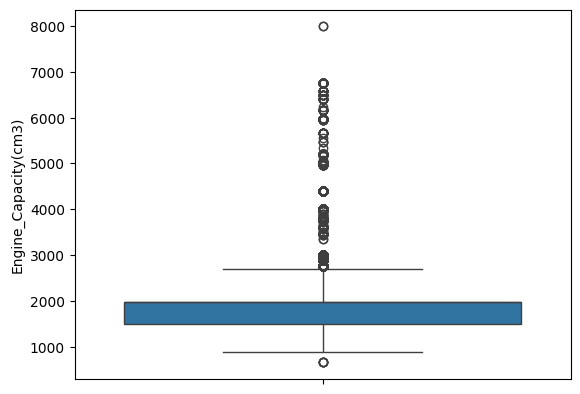

In [431]:
sns.boxplot(df_unique['Engine_Capacity(cm3)'])

Everything seems to be alright

### for Engine Power <--- Nothing to delete

In [432]:
Q1 = df_unique['Engine_Power(kW)'].quantile(0.25)
Q3 = df_unique['Engine_Power(kW)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Engine_Power(kW)'] < lower_bound) |
    (df_unique['Engine_Power(kW)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 5469


In [433]:
df_unique[df_unique['Engine_Power(kW)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)


In [434]:
df_unique[df_unique['Engine_Power(kW)'] > upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
112,1616.0,193.0,petrol,M,1984.0,228.0
118,2015.0,193.0,diesel,M,2925.0,243.0
128,2125.0,244.0,petrol,M,4395.0,390.0
132,2410.0,306.0,petrol,M,4395.0,460.0
135,1965.0,229.0,petrol,M,2993.0,364.0
...,...,...,...,...,...,...
10715129,2535.0,232.0,petrol,M,2998.0,230.0
10720112,2187.0,278.0,petrol,M,3996.0,441.0
10723732,2589.0,294.0,petrol,M,3996.0,404.0
10725475,2274.0,281.0,petrol,M,3996.0,463.0


<Axes: ylabel='Engine_Power(kW)'>

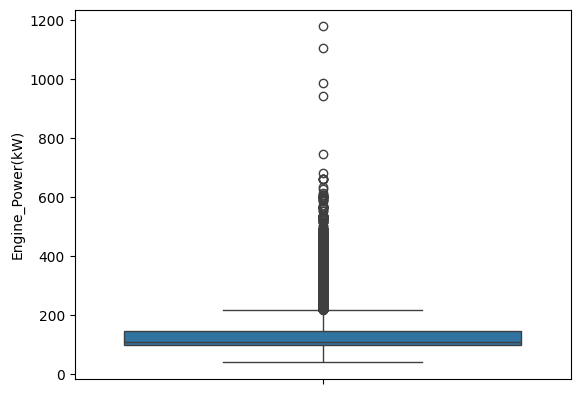

In [435]:
sns.boxplot(df_unique['Engine_Power(kW)'])

### for Mass <--- Nothing to delete

In [436]:
Q1 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_unique['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_unique[
    (df_unique['Mass_in_Running_Order(kg)'] < lower_bound) |
    (df_unique['Mass_in_Running_Order(kg)'] > upper_bound)
]

print(f"Number of outliers (IQR method): {len(outliers_iqr)}")

Number of outliers (IQR method): 703


In [437]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] < lower_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
67407,570.0,109.0,petrol,M,658.0,63.0
1347365,700.0,148.0,petrol,M,1999.0,128.0
1449324,700.0,148.0,petrol,M,1999.0,128.0
2242900,570.0,119.0,petrol,M,658.0,63.0
2423742,668.0,142.0,petrol,M,1598.0,77.0
2701355,658.0,142.0,petrol,M,1598.0,77.0
3296590,700.0,145.0,petrol,M,1596.0,100.0
3486192,570.0,109.0,petrol,M,658.0,63.0
5646783,700.0,206.0,petrol,M,1999.0,177.0
6427683,714.0,134.0,petrol,M,1596.0,165.0


In [438]:
df_unique[df_unique['Mass_in_Running_Order(kg)'] > upper_bound]

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW)
1443,2815.0,292.0,diesel,M,2993.0,183.0
1731,2815.0,313.0,diesel,M,2993.0,183.0
4357,2778.0,322.0,diesel,M,1950.0,140.0
4560,2788.0,322.0,diesel,M,1951.0,140.0
4927,2815.0,312.0,diesel,M,2993.0,183.0
...,...,...,...,...,...,...
10725224,3173.0,284.0,diesel,M,2184.0,118.0
10725255,3080.0,272.0,diesel,M,2184.0,103.0
10725376,3048.0,234.0,diesel,M,2184.0,103.0
10725639,3120.0,239.0,diesel,M,1995.0,125.0


<Axes: ylabel='Mass_in_Running_Order(kg)'>

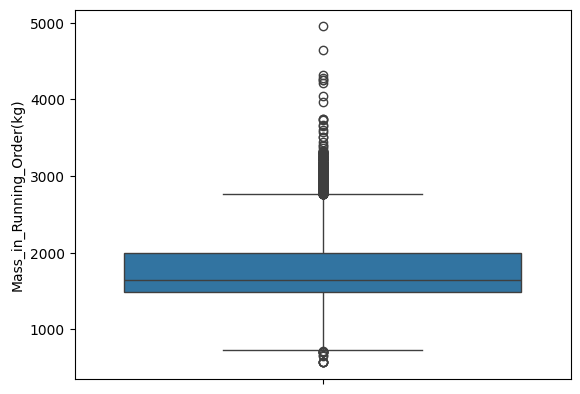

In [439]:
sns.boxplot(df_unique['Mass_in_Running_Order(kg)'])